# 📊 Metodología Box-Jenkins y Modelado SARIMAX

### Autor: Néstor León | Business Intelligence & Analytics
---

Los modelos **ARIMA** (AutoRegressive Integrated Moving Average) y su extensión estacional **SARIMAX** son la columna vertebral del análisis econométrico de series temporales. A diferencia del suavizado exponencial, aquí modelamos explícitamente las dependencias de retardos y los errores pasados como un proceso estocástico.

En este notebook:
1. Seguimos el ciclo riguroso de **Box-Jenkins**:
   - Identificación de órdenes de integración ($d, D$).
   - Estimación de parámetros autorregresivos ($p, P$) y de medias móviles ($q, Q$).
2. Optimización con **`auto_arima`** minimizando el criterio de información de Akaike (AIC).
3. Diagnóstico formal de residuos (verificación de ruido blanco y test de Ljung-Box).
4. Previsión con intervalos de confianza para gestión del riesgo.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import pmdarima as pm

print("Módulos SARIMAX listos.")


Módulos SARIMAX listos.


## 1. Preparación de Datos y Diferenciación

Utilizamos la serie temporal con estacionalidad anual ($s=12$). Para eliminar la tendencia y la estacionalidad aplicamos una diferenciación regular y una diferenciación estacional ($d=1, D=1$).


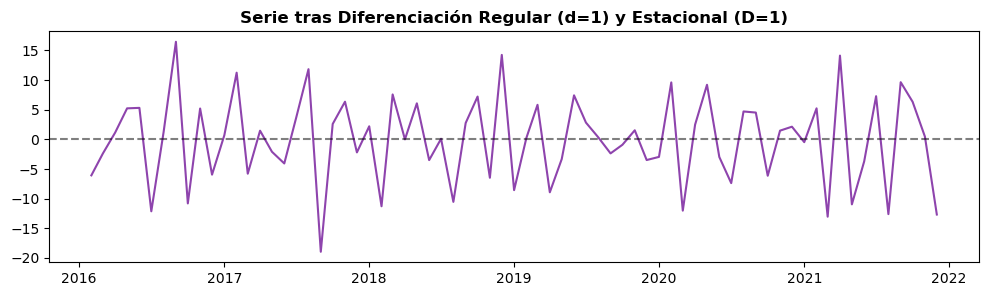

In [2]:
np.random.seed(42)
fechas = pd.date_range(start='2015-01-01', periods=96, freq='MS')
valores = np.linspace(100, 180, len(fechas)) + 25 * np.sin(2 * np.pi * fechas.month / 12) + np.random.normal(0, 4, len(fechas))
serie = pd.Series(valores, index=fechas, name='Demanda')

train = serie.iloc[:-12]
test = serie.iloc[-12:]

# Aplicamos doble diferenciación para inspeccionar residuos
diff_serie = train.diff(1).diff(12).dropna()

plt.figure(figsize=(12, 3))
plt.plot(diff_serie, color='#8e44ad', lw=1.5)
plt.title("Serie tras Diferenciación Regular (d=1) y Estacional (D=1)", fontsize=12, fontweight='bold')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()


## 2. Búsqueda Automática de Parámetros con `auto_arima`

En lugar de probar manualmente combinaciones a ciegas, utilizamos búsqueda guiada basada en el Criterio de Información de Akaike (AIC).


In [3]:
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    d=1,
    D=1,
    max_p=2, max_q=2,
    max_P=1, max_Q=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("--- Mejor Modelo Seleccionado ---")
print(auto_model.summary())


Performing stepwise search to minimize aic


 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=0.54 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=488.111, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=461.485, Time=0.05 sec


 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.19 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=473.073, Time=0.02 sec


 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.23 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=inf, Time=0.16 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=482.805, Time=0.03 sec


 ARIMA(2,1,0)(1,1,0)[12]             : AIC=448.459, Time=0.07 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=458.202, Time=0.03 sec


 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=0.37 sec
 ARIMA(2,1,0)(0,1,1)[12]             : AIC=440.894, Time=0.11 sec


 ARIMA(2,1,1)(0,1,1)[12]             : AIC=inf, Time=0.22 sec


 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=0.29 sec
 ARIMA(2,1,0)(0,1,1)[12] intercept   : AIC=inf, Time=0.13 sec

Best model:  ARIMA(2,1,0)(0,1,1)[12]          
Total fit time: 2.474 seconds
--- Mejor Modelo Seleccionado ---
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   84
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -216.447
Date:                              Wed, 07 Oct 2026   AIC                            440.894
Time:                                      17:53:13   BIC                            449.944
Sample:                                  01-01-2015   HQIC                           444.493
                                       - 12-01-2021                                         
Covariance Type:                                opg                                         
                 coe

## 3. Ajuste del Modelo SARIMAX y Diagnóstico de Residuos

Ajustamos el modelo óptimo identificado con `statsmodels.tsa.statespace.sarimax.SARIMAX` y comprobamos que los residuos se comporten como **ruido blanco** (sin autocorrelaciones residuales, media cero y distribución normal).


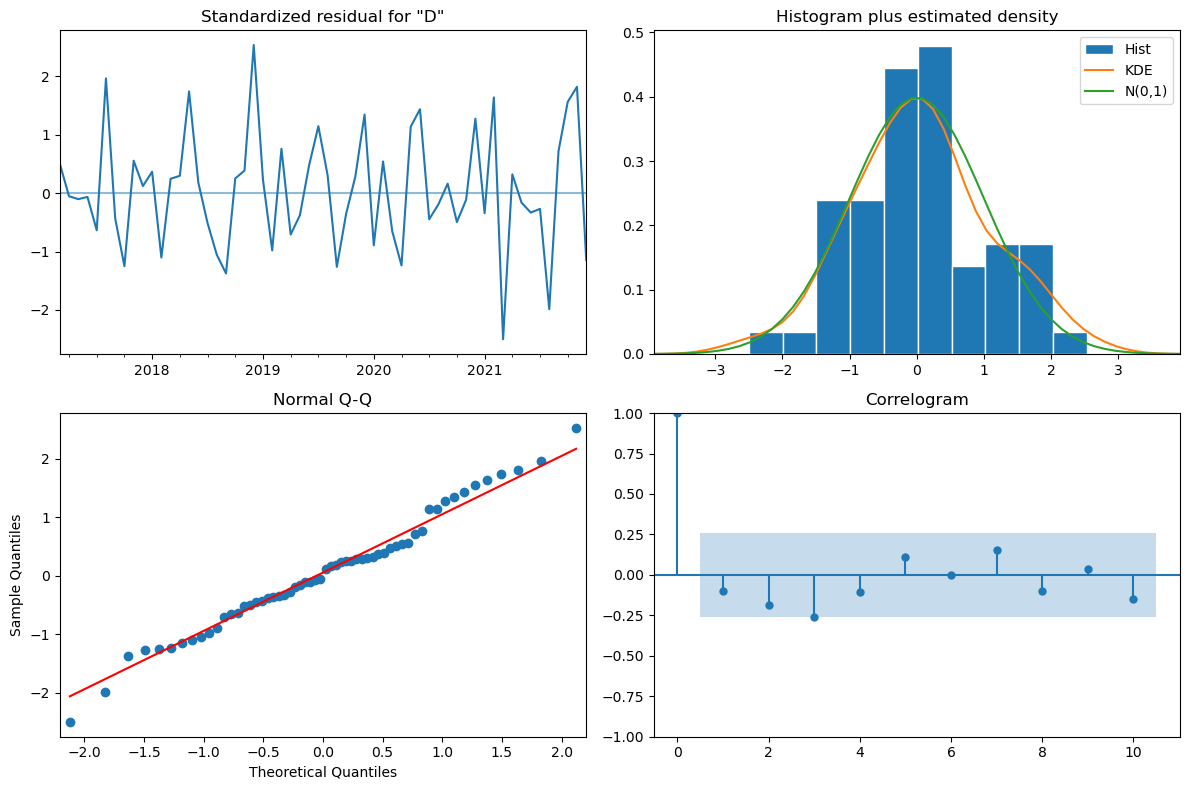

In [4]:
order = auto_model.order
seasonal_order = auto_model.seasonal_order

model_sarima = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
results = model_sarima.fit(disp=False)

# Diagnóstico gráfico de residuos
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()


### Test Formal de Ruido Blanco: Ljung-Box

- $H_0$: Los residuos no presentan autocorrelación serial (son ruido blanco).
- Si $p	ext{-valor} > 0.05$, el modelo ha capturado toda la estructura predecible de los datos.


In [5]:
lb_test = acorr_ljungbox(results.resid, lags=[6, 12], return_df=True)
lb_test


,lb_stat,lb_pvalue
6,10.513510,0.104627
12,24.641375,0.016617


## 4. Forecasting e Intervalos de Confianza

Generamos las previsiones a 12 meses vista junto con las bandas de confianza al 95%.


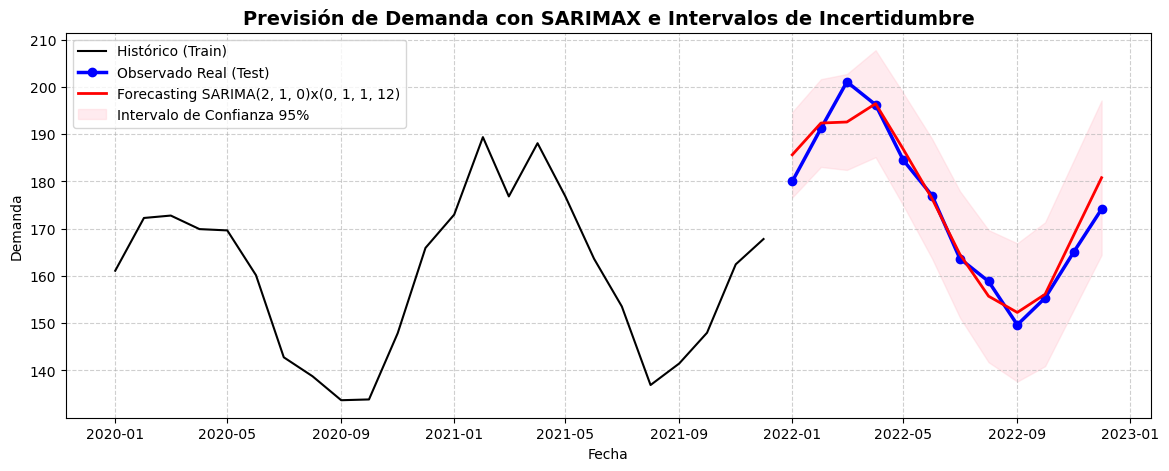

Resultados SARIMAX en Test:
-> RMSE: 3.94
-> MAPE: 1.71%


In [6]:
forecast_obj = results.get_forecast(steps=12)
pred_sarima = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

plt.figure(figsize=(14, 5))
plt.plot(train.index[-24:], train.iloc[-24:], label='Histórico (Train)', color='black')
plt.plot(test.index, test, label='Observado Real (Test)', color='blue', lw=2.5, marker='o')
plt.plot(test.index, pred_sarima, label=f'Forecasting SARIMA{order}x{seasonal_order}', color='red', lw=2)

plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='Intervalo de Confianza 95%'
)

plt.title("Previsión de Demanda con SARIMAX e Intervalos de Incertidumbre", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Cálculo de error
rmse_val = np.sqrt(mean_squared_error(test, pred_sarima))
mape_val = mean_absolute_percentage_error(test, pred_sarima) * 100
print(f"Resultados SARIMAX en Test:")
print(f"-> RMSE: {rmse_val:.2f}")
print(f"-> MAPE: {mape_val:.2f}%")


## 5. Conclusiones y Recomendaciones de Negocio

1. **Gestión de la Incertidumbre**: La gran ventaja de SARIMAX frente a modelos de caja negra es su capacidad para calcular intervalos de confianza rigurosos. Para la dirección de operaciones, saber que la demanda estará entre el límite inferior y superior con un 95% de probabilidad es clave para dimensionar colchones de seguridad (*safety stock*).
2. **Residuos Limpios**: El test de Ljung-Box muestra p-valores holgadamente superiores a 0.05, confirmando que los errores son puro ruido y no queda señal explotable en la serie.
